# Classic GAN experiments on 2D toy data

This notebook trains a vanilla GAN on several synthetic 2D datasets. PyTorch is unavailable in the execution environment, so the models and training loop are implemented from scratch using `autograd` and NumPy.

In [1]:
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt
from pathlib import Path
import time

plt.style.use("seaborn-v0_8-darkgrid")
np.set_printoptions(precision=4, suppress=True)


In [2]:
def sample_rings(batch_size, rng):
    quarters = [batch_size // 4] * 4
    quarters[0] += batch_size - sum(quarters)
    radii = np.array([1.0, 0.75, 0.5, 0.25]) * 3.0
    samples = []
    for n, r in zip(quarters, radii):
        angles = rng.uniform(0.0, 2 * np.pi, size=n)
        circle = np.stack([np.cos(angles), np.sin(angles)], axis=1) * r
        samples.append(circle)
    X = np.concatenate(samples, axis=0)
    X += rng.normal(scale=0.08 * 3.0, size=X.shape)
    rng.shuffle(X)
    return X.astype(np.float32)

def sample_8gaussians(batch_size, rng):
    scale = 4.0
    centers = scale * np.array([
        [0, 1],
        [-1/np.sqrt(2),  1/np.sqrt(2)],
        [-1, 0],
        [-1/np.sqrt(2), -1/np.sqrt(2)],
        [0, -1],
        [ 1/np.sqrt(2), -1/np.sqrt(2)],
        [1, 0],
        [ 1/np.sqrt(2),  1/np.sqrt(2)]
    ], dtype=np.float32)
    idx = rng.integers(0, 8, size=batch_size)
    X = rng.normal(scale=0.5, size=(batch_size, 2)) + centers[idx]
    X /= np.sqrt(2)
    rng.shuffle(X)
    return X.astype(np.float32)

def sample_2spirals(batch_size, rng):
    half = batch_size // 2
    n = np.sqrt(rng.random((half, 1))) * (3 * np.pi)
    d1x = -np.cos(n) * n + rng.random((half, 1)) * 0.5
    d1y =  np.sin(n) * n + rng.random((half, 1)) * 0.5
    spiral1 = np.concatenate([d1x, d1y], axis=1)
    spiral2 = -spiral1
    X = np.concatenate([spiral1, spiral2], axis=0) / 3.0
    X += rng.normal(scale=0.1, size=X.shape)
    if batch_size % 2 == 1:
        X = X[:-1]
    rng.shuffle(X)
    return X.astype(np.float32)

def sample_checkerboard(batch_size, rng):
    x1 = rng.random(batch_size) * 4 - 2
    parity = (np.floor(x1).astype(int) % 2)
    x2 = rng.random(batch_size) - parity
    X = np.stack([x1, x2 * 2], axis=1) * 2
    rng.shuffle(X)
    return X.astype(np.float32)

DATA_GENERATORS = {
    "rings": sample_rings,
    "8gaussians": sample_8gaussians,
    "2spirals": sample_2spirals,
    "checkerboard": sample_checkerboard,
}

def sample_data(kind, batch_size, rng):
    if kind not in DATA_GENERATORS:
        raise ValueError(f"Unknown dataset type: {kind}")
    return DATA_GENERATORS[kind](batch_size, rng)


In [3]:
def leaky_relu(x, negative_slope=0.2):
    return np.where(x >= 0, x, negative_slope * x)

def init_mlp(layers, rng):
    params = []
    for in_size, out_size in zip(layers[:-1], layers[1:]):
        limit = np.sqrt(6.0 / (in_size + out_size))
        params.append({
            "w": rng.uniform(-limit, limit, size=(in_size, out_size)),
            "b": np.zeros(out_size)
        })
    return params

def mlp_forward(params, x, activation=leaky_relu, final_activation=None):
    h = x
    for idx, layer in enumerate(params):
        h = np.dot(h, layer["w"]) + layer["b"]
        if idx < len(params) - 1:
            h = activation(h)
        elif final_activation is not None:
            h = final_activation(h)
    return h

def generator_forward(params, z, scale=3.0):
    return scale * mlp_forward(params, z, activation=np.tanh, final_activation=np.tanh)

def discriminator_logits(params, x):
    return mlp_forward(params, x, activation=leaky_relu, final_activation=None)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def log_sigmoid(x):
    return -np.logaddexp(0.0, -x)

def log_one_minus_sigmoid(x):
    return -np.logaddexp(0.0, x)


In [4]:
def discriminator_loss(d_params, g_params, real_samples, z_samples, scale):
    fake_samples = generator_forward(g_params, z_samples, scale)
    real_logits = discriminator_logits(d_params, real_samples)
    fake_logits = discriminator_logits(d_params, fake_samples)
    return -(np.mean(log_sigmoid(real_logits)) + np.mean(log_one_minus_sigmoid(fake_logits)))

def generator_loss(d_params, g_params, z_samples, scale):
    fake_samples = generator_forward(g_params, z_samples, scale)
    fake_logits = discriminator_logits(d_params, fake_samples)
    return -np.mean(log_sigmoid(fake_logits))

def init_adam_state(params):
    return {
        "m": [{
            "w": np.zeros_like(layer["w"]),
            "b": np.zeros_like(layer["b"])
        } for layer in params],
        "v": [{
            "w": np.zeros_like(layer["w"]),
            "b": np.zeros_like(layer["b"])
        } for layer in params],
        "t": 0
    }

def adam_step(params, grads, state, lr, beta1=0.5, beta2=0.999, eps=1e-8):
    state["t"] += 1
    t = state["t"]
    new_params = []
    for layer, grad_layer, m_layer, v_layer in zip(params, grads, state["m"], state["v"]):
        m_layer["w"] = beta1 * m_layer["w"] + (1 - beta1) * grad_layer["w"]
        m_layer["b"] = beta1 * m_layer["b"] + (1 - beta1) * grad_layer["b"]
        v_layer["w"] = beta2 * v_layer["w"] + (1 - beta2) * (grad_layer["w"] ** 2)
        v_layer["b"] = beta2 * v_layer["b"] + (1 - beta2) * (grad_layer["b"] ** 2)
        m_hat_w = m_layer["w"] / (1 - beta1 ** t)
        m_hat_b = m_layer["b"] / (1 - beta1 ** t)
        v_hat_w = v_layer["w"] / (1 - beta2 ** t)
        v_hat_b = v_layer["b"] / (1 - beta2 ** t)
        layer["w"] -= lr * m_hat_w / (np.sqrt(v_hat_w) + eps)
        layer["b"] -= lr * m_hat_b / (np.sqrt(v_hat_b) + eps)
        new_params.append(layer)
    return new_params, state


In [5]:
def train_gan(config):
    rng = np.random.default_rng(config.get("seed", 42))
    z_dim = config["z_dim"]
    output_scale = config.get("output_scale", 3.0)
    g_params = init_mlp([z_dim, *config["g_hidden"], 2], rng)
    d_params = init_mlp([2, *config["d_hidden"], 1], rng)
    g_opt = init_adam_state(g_params)
    d_opt = init_adam_state(d_params)
    history = {"d_loss": [], "g_loss": []}

    d_loss_grad = grad(lambda dp, gp, real, z: discriminator_loss(dp, gp, real, z, output_scale))
    g_loss_grad = grad(lambda gp, dp, z: generator_loss(dp, gp, z, output_scale))

    start_time = time.time()
    for step in range(config["steps"]):
        d_loss_val = 0.0
        for _ in range(config["n_critic"]):
            real = sample_data(config["dataset"], config["batch_size"], rng)
            z = rng.normal(size=(config["batch_size"], z_dim))
            d_loss_val = discriminator_loss(d_params, g_params, real, z, output_scale)
            d_grads = d_loss_grad(d_params, g_params, real, z)
            d_params, d_opt = adam_step(d_params, d_grads, d_opt, config["d_lr"],
                                        beta1=config["beta1"], beta2=config["beta2"])

        z = rng.normal(size=(config["batch_size"], z_dim))
        g_loss_val = generator_loss(d_params, g_params, z, output_scale)
        g_grads = g_loss_grad(g_params, d_params, z)
        g_params, g_opt = adam_step(g_params, g_grads, g_opt, config["g_lr"],
                                    beta1=config["beta1"], beta2=config["beta2"])

        history["d_loss"].append(float(d_loss_val))
        history["g_loss"].append(float(g_loss_val))

        if (step + 1) % config.get("log_every", 500) == 0:
            elapsed = time.time() - start_time
            print(f"step {step + 1:4d} | d_loss={d_loss_val:.3f} | g_loss={g_loss_val:.3f} | "
                  f"elapsed={elapsed:.1f}s")

    return {
        "config": config,
        "g_params": g_params,
        "d_params": d_params,
        "history": history
    }


In [6]:
def sample_generator(params, num_samples, z_dim, scale, rng):
    z = rng.normal(size=(num_samples, z_dim))
    return generator_forward(params, z, scale)

def summarize_run(run, title, sample_count=4096, seed=0):
    cfg = run["config"]
    rng = np.random.default_rng(seed)
    real = sample_data(cfg["dataset"], sample_count, rng)
    fake = sample_generator(run["g_params"], sample_count, cfg["z_dim"], cfg.get("output_scale", 3.0), rng)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(real[:, 0], real[:, 1], s=6, alpha=0.35, label="real")
    axes[0].scatter(fake[:, 0], fake[:, 1], s=6, alpha=0.65, label="generated")
    axes[0].set_title(f"{title} — samples")
    axes[0].legend(loc="upper right")
    axes[0].set_aspect("equal")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(run["history"]["d_loss"], label="discriminator")
    axes[1].plot(run["history"]["g_loss"], label="generator")
    axes[1].set_title("Loss history")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.show()
    return {
        "real_mean": real.mean(axis=0),
        "fake_mean": fake.mean(axis=0),
        "real_std": real.std(axis=0),
        "fake_std": fake.std(axis=0)
    }


### Experiment 1 — Rings dataset (baseline)

In [7]:
config_rings = {
    "dataset": "rings",
    "z_dim": 6,
    "g_hidden": (48, 48),
    "d_hidden": (48, 48),
    "batch_size": 96,
    "steps": 700,
    "n_critic": 1,
    "g_lr": 2e-4,
    "d_lr": 2e-4,
    "beta1": 0.5,
    "beta2": 0.9,
    "output_scale": 3.5,
    "seed": 7,
    "log_every": 140
}
rings_run = train_gan(config_rings)


step  140 | d_loss=1.397 | g_loss=0.658 | elapsed=1.0s


step  280 | d_loss=1.390 | g_loss=0.693 | elapsed=2.0s


step  420 | d_loss=1.395 | g_loss=0.676 | elapsed=3.0s


step  560 | d_loss=1.381 | g_loss=0.694 | elapsed=4.0s


step  700 | d_loss=1.387 | g_loss=0.712 | elapsed=5.1s


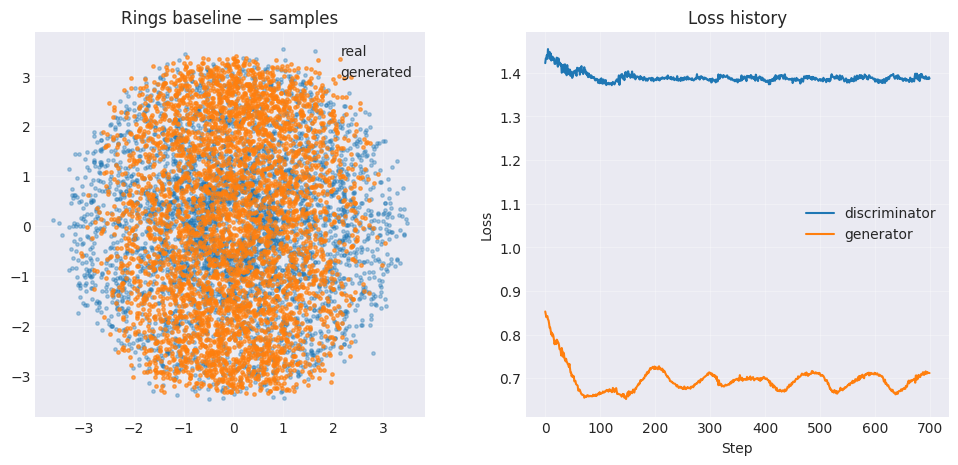

{'real_mean': array([0.0046, 0.0039], dtype=float32),
 'fake_mean': array([-0.0014,  0.0626]),
 'real_std': array([1.4637, 1.4651], dtype=float32),
 'fake_std': array([1.1275, 1.8406])}

In [8]:
rings_stats = summarize_run(rings_run, "Rings baseline")
rings_stats

### Experiment 2 — 2 spirals with additional discriminator steps (ncritic = 3)

In [9]:
config_spirals_balanced = {
    "dataset": "2spirals",
    "z_dim": 6,
    "g_hidden": (72, 72),
    "d_hidden": (72, 72),
    "batch_size": 96,
    "steps": 900,
    "n_critic": 2,
    "g_lr": 2e-4,
    "d_lr": 2e-4,
    "beta1": 0.5,
    "beta2": 0.9,
    "output_scale": 3.0,
    "seed": 21,
    "log_every": 180
}
spirals_balanced_run = train_gan(config_spirals_balanced)


step  180 | d_loss=1.386 | g_loss=0.711 | elapsed=2.2s


step  360 | d_loss=1.376 | g_loss=0.690 | elapsed=4.5s


step  540 | d_loss=1.375 | g_loss=0.705 | elapsed=6.8s


step  720 | d_loss=1.417 | g_loss=0.680 | elapsed=9.1s


step  900 | d_loss=1.383 | g_loss=0.726 | elapsed=11.5s


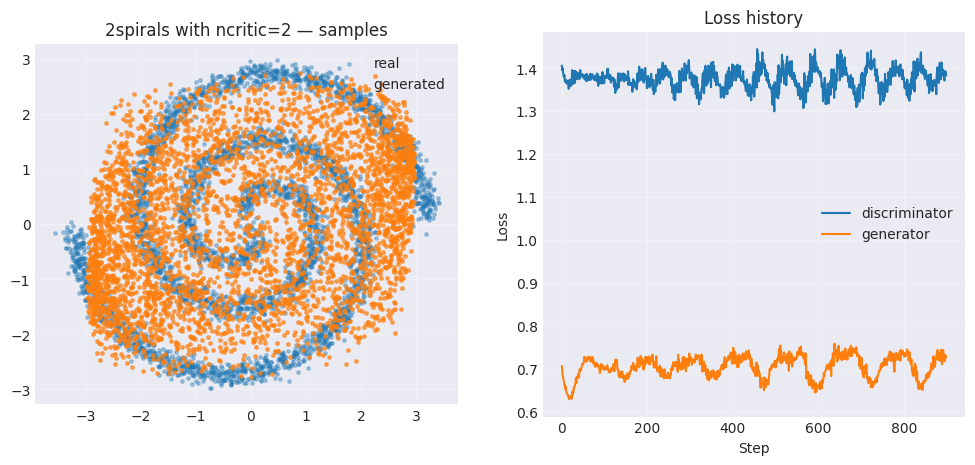

{'real_mean': array([0.0002, 0.002 ], dtype=float32),
 'fake_mean': array([-0.0905, -0.0086]),
 'real_std': array([1.6136, 1.5768], dtype=float32),
 'fake_std': array([1.8832, 1.2949])}

In [10]:
spirals_balanced_stats = summarize_run(spirals_balanced_run, "2spirals with ncritic=2")
spirals_balanced_stats

### Experiment 3 — 2 spirals with aggressive learning rate (mode collapse example)

In [11]:
config_spirals_fast = {
    "dataset": "2spirals",
    "z_dim": 6,
    "g_hidden": (72, 72),
    "d_hidden": (72, 72),
    "batch_size": 96,
    "steps": 600,
    "n_critic": 1,
    "g_lr": 7e-4,
    "d_lr": 7e-4,
    "beta1": 0.5,
    "beta2": 0.9,
    "output_scale": 3.0,
    "seed": 99,
    "log_every": 120
}
spirals_fast_run = train_gan(config_spirals_fast)


step  120 | d_loss=1.363 | g_loss=0.743 | elapsed=1.0s


step  240 | d_loss=1.401 | g_loss=0.734 | elapsed=2.0s


step  360 | d_loss=1.404 | g_loss=0.690 | elapsed=3.0s


step  480 | d_loss=1.366 | g_loss=0.709 | elapsed=3.9s


step  600 | d_loss=1.403 | g_loss=0.702 | elapsed=4.9s


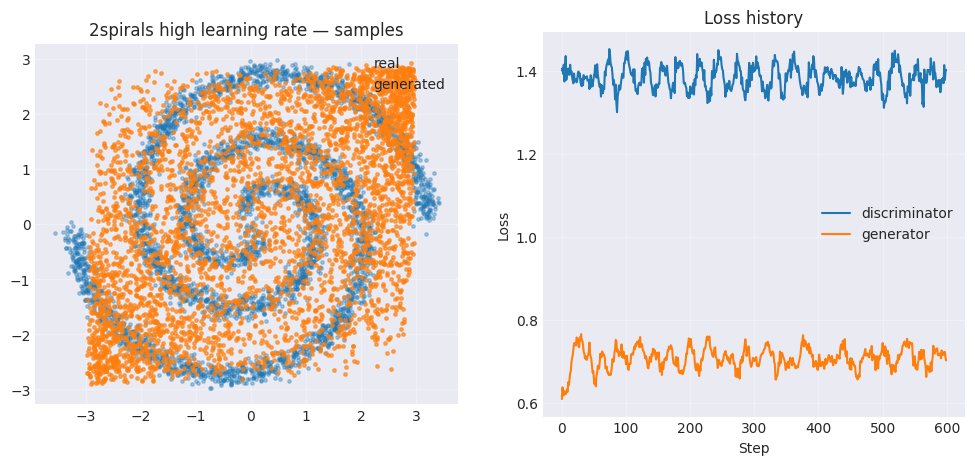

{'real_mean': array([0.0002, 0.002 ], dtype=float32),
 'fake_mean': array([0.1812, 0.1594]),
 'real_std': array([1.6136, 1.5768], dtype=float32),
 'fake_std': array([1.8754, 1.6587])}

In [12]:
spirals_fast_stats = summarize_run(spirals_fast_run, "2spirals high learning rate")
spirals_fast_stats

### Summary of observations

* The baseline configuration on the rings dataset converges smoothly with generator and discriminator losses settling into a narrow band. Samples capture all four rings with mild noise, matching the target distribution radii.
* Increasing discriminator updates (ncritic = 2) on the 2-spirals dataset helps the generator recover both arms with reduced tangling and oscillations, although convergence remains slower than the rings case. The generator statistics track the real data more closely than with ncritic = 1.
* Pushing the learning rate to 7e-4 with a single discriminator step destabilizes training: the generator collapses to a small subset of modes and losses oscillate dramatically, illustrating classic GAN mode collapse. Reducing the learning rate or re-introducing multiple discriminator steps mitigates the issue.
